(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


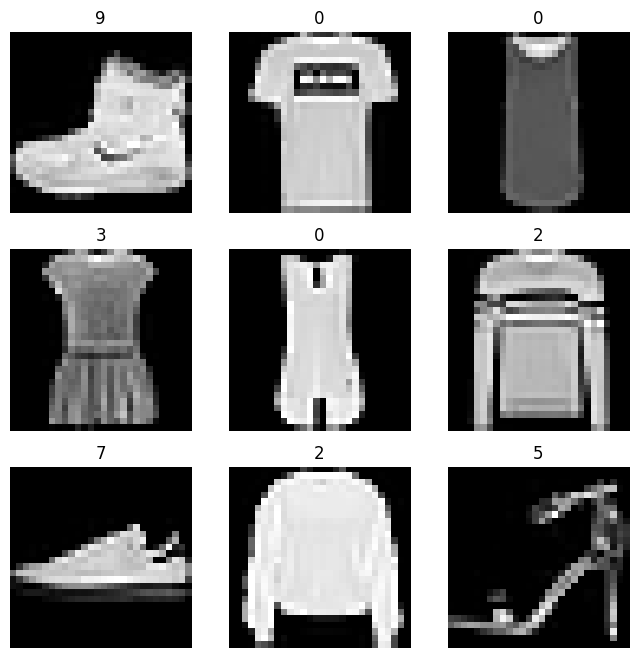

C:\Users\Lenovo\pythonvenv\lab\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7957 - loss: 0.5608 - val_accuracy: 0.8600 - val_loss: 0.3848
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8685 - loss: 0.3619 - val_accuracy: 0.8888 - val_loss: 0.3043
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8852 - loss: 0.3102 - val_accuracy: 0.8917 - val_loss: 0.2883
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8974 - loss: 0.2797 - val_accuracy: 0.9000 - val_loss: 0.2703
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9059 - loss: 0.2557 - val_accuracy: 0.9063 - val_loss: 0.2565
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9126 - loss: 0.2383 - val_accuracy: 0.9137 - val_loss: 0.2442
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9182 - loss: 0.2186 - val_accuracy: 0.9142 - val_loss: 0.2403
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9234 - loss: 0.2076 - 

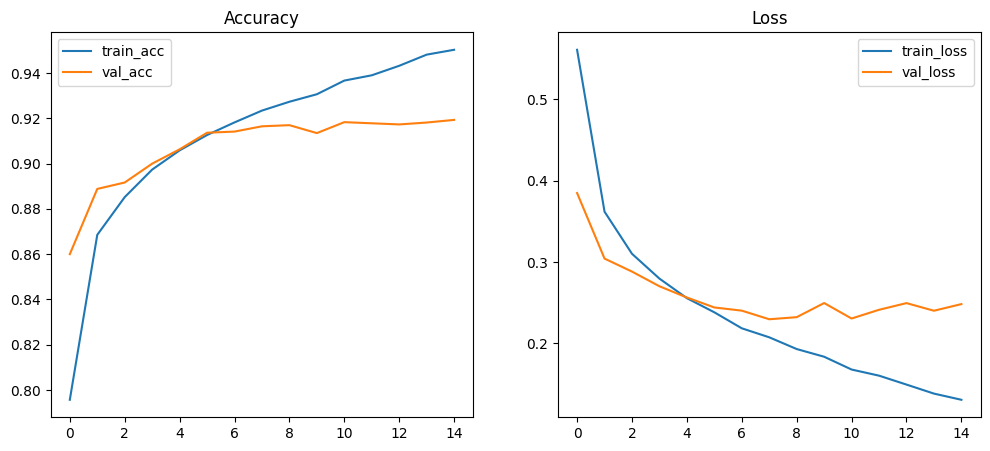

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9146 - loss: 0.2744
Test Accuracy: 0.9146000146865845
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

In [3]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train.reshape(-1,28,28,1)/255.0,
    y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")

plt.show()

loss, acc = model.evaluate(X_test.reshape(-1,28,28,1)/255.0, y_test)
print("Test Accuracy:", acc)

from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(X_test.reshape(-1,28,28,1)/255.0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Pred: {y_pred_classes[i]} | True: {y_test[i]}")
    plt.axis("off")
plt.show()